<center>

# **Preprocesamiento de Datos**

</center>

---

## **Objetivo**

Preparar los datos para el modelado de Machine Learning siguiendo las recomendaciones del EDA:

1. Eliminar valores faltantes
2. Codificar variables categóricas
3. Escalar variables numéricas
4. Aplicar balanceo de clases
5. Dividir datos (Train/Val/Test)
6. Guardar datos procesados

## **1. Importar Librerías**

In [19]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from pathlib import Path

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Balanceo de clases
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('default')
sns.set_palette("pastel")
pd.set_option('display.max_columns', None)

print(" Librerías importadas correctamente")

 Librerías importadas correctamente


## **2. Cargar Datos**

In [20]:
# Cargar dataset
df = pd.read_csv('data/raw/diabetic_data.csv')
df = df.replace('?', np.nan)  # Reemplazar '?' por NaN

print(f" Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

# Crear variable objetivo
df['target'] = df['readmitted'].isin(['<30', '>30']).astype(int)
df.drop(columns=['readmitted'], inplace=True)

print(f"\n Variable 'target' creada:")
print(df['target'].value_counts())
print(f"\nRatio de desbalance: {(df['target']==0).sum() / (df['target']==1).sum():.2f}:1")

 Dataset cargado: 101,766 filas x 50 columnas

 Variable 'target' creada:
target
0    54864
1    46902
Name: count, dtype: int64

Ratio de desbalance: 1.17:1


## **3. Eliminar Columnas Irrelevantes**

In [21]:
# Columnas a eliminar
columns_to_drop = [
    'encounter_id',      # ID único, no aporta información
    'patient_nbr',       # ID del paciente, no aporta información
    'weight',            # >97% de valores faltantes (según EDA)
    'payer_code',        # Muchos valores faltantes y baja relevancia
    'medical_specialty'  # Muchas categorías y valores faltantes
]

# Eliminar solo las que existen
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_to_drop)

print(f" Columnas eliminadas: {columns_to_drop}")
print(f" Dataset después de eliminar: {df.shape[0]:,} filas x {df.shape[1]} columnas")

 Columnas eliminadas: ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty']
 Dataset después de eliminar: 101,766 filas x 45 columnas


## **4. Crear Variables Agrupadas (del EDA)**

In [22]:
# 4.1. Agrupar Admission Type (si no está ya hecho)
if 'admission_type_group' not in df.columns:
    admission_type_map = {
        1: 'Emergency/Urgent', 2: 'Emergency/Urgent', 7: 'Emergency/Urgent',
        3: 'Elective',
        4: 'Newborn',
        5: np.nan, 6: np.nan, 8: np.nan,
    }
    df['admission_type_group'] = df['admission_type_id'].map(admission_type_map)
    print(" Variable 'admission_type_group' creada")

# 4.2. Agrupar Admission Source (si no está ya hecho)
if 'admission_source_group' not in df.columns:
    admission_map = {
        7: 'Emergency',
        1: 'Referral', 2: 'Referral', 3: 'Referral',
        4: 'Transfer', 5: 'Transfer', 6: 'Transfer', 10: 'Transfer', 
        18: 'Transfer', 19: 'Transfer', 22: 'Transfer', 25: 'Transfer', 26: 'Transfer',
        11: 'Birth-Related', 12: 'Birth-Related', 13: 'Birth-Related', 14: 'Birth-Related',
        23: 'Birth-Related', 24: 'Birth-Related',
        8: 'Other',
        9: np.nan, 15: np.nan, 17: np.nan, 20: np.nan, 21: np.nan
    }
    df['admission_source_group'] = df['admission_source_id'].map(admission_map)
    print(" Variable 'admission_source_group' creada")

# Eliminar variables originales que ya fueron agrupadas
df = df.drop(columns=['admission_type_id', 'admission_source_id', 'discharge_disposition_id'], errors='ignore')

print(f"\n Dataset después de agrupación: {df.shape}")

 Variable 'admission_type_group' creada
 Variable 'admission_source_group' creada

 Dataset después de agrupación: (101766, 44)


## **5. Manejo de Valores Faltantes**

In [23]:
# Analizar valores faltantes
missing_before = df.isnull().sum().sum()
print(f" Valores faltantes antes del tratamiento: {missing_before:,}")

# Identificar columnas con valores faltantes
cols_with_missing = df.columns[df.isnull().any()].tolist()
print(f"\nColumnas con valores faltantes: {len(cols_with_missing)}")
for col in cols_with_missing:
    pct = (df[col].isnull().sum() / len(df)) * 100
    print(f"  - {col}: {pct:.2f}%")

# ESTRATEGIA MEJORADA:
# 1. Eliminar columnas con >80% de valores faltantes
# 2. Imputar valores faltantes en columnas restantes según tipo de variable

print("\n--- PASO 1: Eliminar columnas con >80% de valores faltantes ---")
threshold = 0.80
cols_to_drop = []
for col in df.columns:
    missing_pct = df[col].isnull().sum() / len(df)
    if missing_pct > threshold:
        cols_to_drop.append(col)
        print(f"  Eliminando '{col}': {missing_pct*100:.2f}% faltantes")

df = df.drop(columns=cols_to_drop)
print(f"\n Columnas eliminadas: {len(cols_to_drop)}")
print(f" Dataset despues: {df.shape}")

# 2. Imputar valores faltantes restantes
print("\n--- PASO 2: Imputar valores faltantes restantes ---")

# Columnas numericas: imputar con la mediana
numeric_cols_with_missing = df.select_dtypes(include=[np.number]).columns[
    df.select_dtypes(include=[np.number]).isnull().any()
].tolist()

for col in numeric_cols_with_missing:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)
    print(f"  {col}: imputado con mediana = {median_value:.2f}")

# Columnas categoricas: imputar con la moda
categorical_cols_with_missing = df.select_dtypes(include=['object']).columns[
    df.select_dtypes(include=['object']).isnull().any()
].tolist()

for col in categorical_cols_with_missing:
    mode_value = df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown'
    df[col].fillna(mode_value, inplace=True)
    print(f"  {col}: imputado con moda = '{mode_value}'")

# Verificar que no quedan valores faltantes
missing_after = df.isnull().sum().sum()
print(f"\n Valores faltantes despues del tratamiento: {missing_after:,}")
print(f" Dataset final: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f" Filas conservadas: {len(df) / 101766 * 100:.2f}% del dataset original")

 Valores faltantes antes del tratamiento: 202,706

Columnas con valores faltantes: 8
  - race: 2.23%
  - diag_1: 0.02%
  - diag_2: 0.35%
  - diag_3: 1.40%
  - max_glu_serum: 94.75%
  - A1Cresult: 83.28%
  - admission_type_group: 10.22%
  - admission_source_group: 6.94%

--- PASO 1: Eliminar columnas con >80% de valores faltantes ---
  Eliminando 'max_glu_serum': 94.75% faltantes
  Eliminando 'A1Cresult': 83.28% faltantes

 Columnas eliminadas: 2
 Dataset despues: (101766, 42)

--- PASO 2: Imputar valores faltantes restantes ---

Columnas con valores faltantes: 8
  - race: 2.23%
  - diag_1: 0.02%
  - diag_2: 0.35%
  - diag_3: 1.40%
  - max_glu_serum: 94.75%
  - A1Cresult: 83.28%
  - admission_type_group: 10.22%
  - admission_source_group: 6.94%

--- PASO 1: Eliminar columnas con >80% de valores faltantes ---
  Eliminando 'max_glu_serum': 94.75% faltantes
  Eliminando 'A1Cresult': 83.28% faltantes

 Columnas eliminadas: 2
 Dataset despues: (101766, 42)

--- PASO 2: Imputar valores faltan

## **6. Identificar Tipos de Variables**

In [24]:
# Identificar variables numéricas y categóricas
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('target')  # Excluir la variable objetivo

categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f" Variables numéricas ({len(numeric_features)}): {numeric_features[:10]}...")
print(f"\n Variables categóricas ({len(categorical_features)}): {categorical_features[:10]}...")

 Variables numéricas (8): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']...

 Variables categóricas (33): ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide']...


## **7. Codificación de Variables Categóricas**

In [25]:
# Lista de medicamentos (variables con valores: Up, Down, Steady, No)
drug_columns = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 
                'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
                'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
                'tolazamide', 'examide', 'insulin', 'glyburide-metformin', 
                'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 
                'metformin-pioglitazone']

# Filtrar solo los que existen en el dataframe
drug_columns = [col for col in drug_columns if col in df.columns]

# Codificación ordinal para medicamentos (No < Steady < Down < Up)
drug_mapping = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
for col in drug_columns:
    df[col] = df[col].map(drug_mapping)

print(f" Medicamentos codificados: {len(drug_columns)} variables")

# ESTRATEGIA OPTIMIZADA PARA CODIFICACION
# Reducir dimensionalidad agrupando categorías poco frecuentes

print("\n--- Reduciendo dimensionalidad de variables categóricas ---")

# Variables con diagnósticos (tienen muchas categorías únicas)
diagnosis_cols = ['diag_1', 'diag_2', 'diag_3']

# Agrupar diagnósticos por categoría principal (primeros 3 dígitos)
for col in diagnosis_cols:
    if col in df.columns:
        # Convertir a string y tomar primeros 3 caracteres
        df[col] = df[col].astype(str).str[:3]
        
        # Mantener solo las 20 categorías más frecuentes, resto = 'Other'
        top_20 = df[col].value_counts().head(20).index.tolist()
        df[col] = df[col].apply(lambda x: x if x in top_20 else 'Other')
        
        print(f"  {col}: reducido a {df[col].nunique()} categorías")

# Para otras variables categóricas, mantener solo top N categorías
other_categorical = [col for col in categorical_features 
                     if col not in drug_columns and col not in diagnosis_cols]

for col in other_categorical:
    if col in df.columns:
        n_unique = df[col].nunique()
        if n_unique > 10:  # Si tiene más de 10 categorías
            # Mantener solo las 10 más frecuentes
            top_10 = df[col].value_counts().head(10).index.tolist()
            df[col] = df[col].apply(lambda x: x if x in top_10 else 'Other')
            print(f"  {col}: reducido de {n_unique} a {df[col].nunique()} categorías")

# Variables categóricas a codificar con One-Hot
categorical_to_encode = [col for col in df.select_dtypes(include=['object']).columns 
                         if col not in drug_columns]

print(f"\nCodificando {len(categorical_to_encode)} variables categóricas...")

# One-Hot Encoding (ahora con menos dimensionalidad)
df_encoded = pd.get_dummies(df, columns=categorical_to_encode, drop_first=True, dtype=np.int8)

print(f" Variables categóricas codificadas: {len(categorical_to_encode)}")
print(f" Dataset después de codificación: {df_encoded.shape}")
print(f" Memoria estimada: {df_encoded.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

df = df_encoded.copy()
del df_encoded  # Liberar memoria

 Medicamentos codificados: 22 variables

--- Reduciendo dimensionalidad de variables categóricas ---
  diag_1: reducido a 21 categorías
  diag_2: reducido a 21 categorías
  diag_3: reducido a 21 categorías

Codificando 11 variables categóricas...
  diag_2: reducido a 21 categorías
  diag_3: reducido a 21 categorías

Codificando 11 variables categóricas...
 Variables categóricas codificadas: 11
 Dataset después de codificación: (101766, 114)
 Memoria estimada: 32.12 MB
 Variables categóricas codificadas: 11
 Dataset después de codificación: (101766, 114)
 Memoria estimada: 32.12 MB


## **8. Separar Features y Target**

In [26]:
# Separar X (features) y (target)
X = df.drop(columns=['target'])
y = df['target']

print(f" X (features): {X.shape}")
print(f" y (target): {y.shape}")
print(f"\n Balance de clases en y:")
print(y.value_counts())
print(f"\nRatio: {(y==0).sum() / (y==1).sum():.2f}:1")

 X (features): (101766, 113)
 y (target): (101766,)

 Balance de clases en y:
target
0    54864
1    46902
Name: count, dtype: int64

Ratio: 1.17:1


## **9. División Train/Val/Test (70/15/15)**

In [27]:
# Primera división: Train (70%) vs Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Segunda división: Temp -> Val (15%) y Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(" División de datos:")
print(f"  Train: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Val:   {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test:  {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\n Balance de clases preservado:")
print(f"  Train: {y_train.value_counts().to_dict()}")
print(f"  Val:   {y_val.value_counts().to_dict()}")
print(f"  Test:  {y_test.value_counts().to_dict()}")

 División de datos:
  Train: 71,236 (70.0%)
  Val:   15,265 (15.0%)
  Test:  15,265 (15.0%)

 Balance de clases preservado:
  Train: {0: 38405, 1: 32831}
  Val:   {0: 8229, 1: 7036}
  Test:  {0: 8230, 1: 7035}


## **10. Escalado de Variables Numéricas**

In [28]:
# Identificar columnas numéricas en X_train
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f" Variables numéricas a escalar: {len(numeric_cols)}")

# Crear y ajustar el scaler SOLO con datos de train
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("\n Variables escaladas (StandardScaler)")
print(f"  Media train: {X_train[numeric_cols].mean().mean():.2e}")
print(f"  Std train: {X_train[numeric_cols].std().mean():.2f}")

 Variables numéricas a escalar: 113

 Variables escaladas (StandardScaler)
  Media train: -2.70e-19
  Std train: 0.98

 Variables escaladas (StandardScaler)
  Media train: -2.70e-19
  Std train: 0.98


## **11. Balanceo de Clases (SOLO en Train)**

In [29]:
print(" Aplicando SMOTE para balancear clases en Train...")
print(f"\nAntes del balanceo:")
print(f"  Clase 0: {(y_train==0).sum():,}")
print(f"  Clase 1: {(y_train==1).sum():,}")
print(f"  Ratio: {(y_train==0).sum() / (y_train==1).sum():.2f}:1")

# Determinar la estrategia de balanceo basada en el ratio actual
ratio_actual = (y_train==0).sum() / (y_train==1).sum()

if ratio_actual > 1.5:
    # Solo aplicar SMOTE si hay suficiente desbalance
    # sampling_strategy='auto' balancea 1:1
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    
    print(f"\nDespués del balanceo:")
    print(f"  Clase 0: {(y_train_balanced==0).sum():,}")
    print(f"  Clase 1: {(y_train_balanced==1).sum():,}")
    print(f"  Ratio: {(y_train_balanced==0).sum() / (y_train_balanced==1).sum():.2f}:1")
    print(f"\n Muestras sintéticas generadas: {len(X_train_balanced) - len(X_train):,}")
else:
    # Si ya está balanceado, no aplicar SMOTE
    print(f"\n Las clases ya están balanceadas (ratio {ratio_actual:.2f}:1)")
    print(" No se aplicará SMOTE")
    X_train_balanced = X_train
    y_train_balanced = y_train

# Guardar versiones balanceadas
X_train_final = X_train_balanced
y_train_final = y_train_balanced

 Aplicando SMOTE para balancear clases en Train...

Antes del balanceo:
  Clase 0: 38,405
  Clase 1: 32,831
  Ratio: 1.17:1

 Las clases ya están balanceadas (ratio 1.17:1)
 No se aplicará SMOTE


## **12. Visualización del Balance**

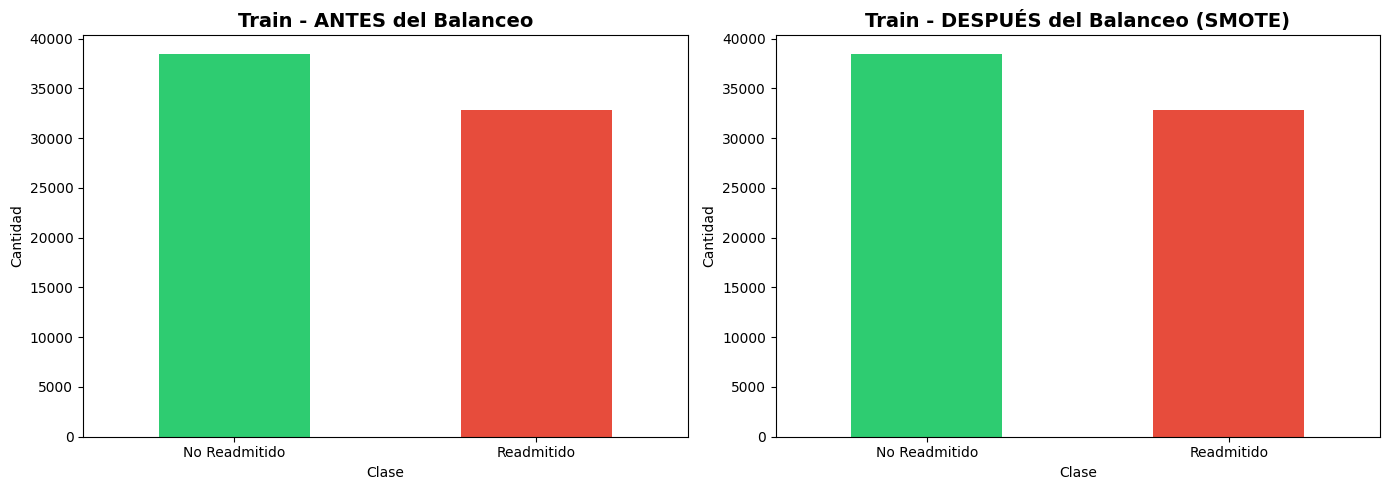

 Visualización completada


In [30]:
# Comparar antes y después del balanceo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Train - ANTES del Balanceo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['No Readmitido', 'Readmitido'], rotation=0)

# Después
y_train_final.value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Train - DESPUÉS del Balanceo (SMOTE)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Cantidad')
axes[1].set_xticklabels(['No Readmitido', 'Readmitido'], rotation=0)

plt.tight_layout()
plt.show()

print(" Visualización completada")

## **13. Resumen del Preprocesamiento**

In [31]:
print("="*80)
print(" "*20 + "RESUMEN DEL PREPROCESAMIENTO")
print("="*80)

print("\n TRANSFORMACIONES APLICADAS:")
print("   Eliminación de columnas irrelevantes (IDs, weight, etc.)")
print("   Agrupación de categorías (admission_type, admission_source)")
print("   Eliminación de filas con valores faltantes")
print("   Codificación ordinal de medicamentos (No/Steady/Down/Up)")
print("   One-Hot Encoding de variables categóricas")
print("   Escalado de variables numéricas (StandardScaler)")
print("   Balanceo de clases en Train (SMOTE)")

print("\n DIMENSIONES FINALES:")
print(f"  Train (balanceado): {X_train_final.shape}")
print(f"  Validation:         {X_val.shape}")
print(f"  Test:               {X_test.shape}")

print("\n BALANCE DE CLASES:")
print(f"  Train:")
print(f"    Clase 0: {(y_train_final==0).sum():,} ({(y_train_final==0).sum()/len(y_train_final)*100:.1f}%)")
print(f"    Clase 1: {(y_train_final==1).sum():,} ({(y_train_final==1).sum()/len(y_train_final)*100:.1f}%)")
print(f"  Validation:")
print(f"    Clase 0: {(y_val==0).sum():,} ({(y_val==0).sum()/len(y_val)*100:.1f}%)")
print(f"    Clase 1: {(y_val==1).sum():,} ({(y_val==1).sum()/len(y_val)*100:.1f}%)")
print(f"  Test:")
print(f"    Clase 0: {(y_test==0).sum():,} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
print(f"    Clase 1: {(y_test==1).sum():,} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")

print("\n" + "="*80)
print(" PREPROCESAMIENTO COMPLETADO")
print("="*80)

                    RESUMEN DEL PREPROCESAMIENTO

 TRANSFORMACIONES APLICADAS:
   Eliminación de columnas irrelevantes (IDs, weight, etc.)
   Agrupación de categorías (admission_type, admission_source)
   Eliminación de filas con valores faltantes
   Codificación ordinal de medicamentos (No/Steady/Down/Up)
   One-Hot Encoding de variables categóricas
   Escalado de variables numéricas (StandardScaler)
   Balanceo de clases en Train (SMOTE)

 DIMENSIONES FINALES:
  Train (balanceado): (71236, 113)
  Validation:         (15265, 113)
  Test:               (15265, 113)

 BALANCE DE CLASES:
  Train:
    Clase 0: 38,405 (53.9%)
    Clase 1: 32,831 (46.1%)
  Validation:
    Clase 0: 8,229 (53.9%)
    Clase 1: 7,036 (46.1%)
  Test:
    Clase 0: 8,230 (53.9%)
    Clase 1: 7,035 (46.1%)

 PREPROCESAMIENTO COMPLETADO


## **14. Guardar Datos Procesados**

In [32]:
# Crear directorio si no existe
Path('data/processed').mkdir(parents=True, exist_ok=True)

# Guardar datos procesados
print(" Guardando datos procesados...")

X_train_final.to_csv('data/processed/X_train.csv', index=False)
X_val.to_csv('data/processed/X_val.csv', index=False)
X_test.to_csv('data/processed/X_test.csv', index=False)

y_train_final.to_csv('data/processed/y_train.csv', index=False)
y_val.to_csv('data/processed/y_val.csv', index=False)
y_test.to_csv('data/processed/y_test.csv', index=False)

print("\n Datos guardados en 'data/processed/':")
print("  - X_train.csv")
print("  - X_val.csv")
print("  - X_test.csv")
print("  - y_train.csv")
print("  - y_val.csv")
print("  - y_test.csv")

 Guardando datos procesados...

 Datos guardados en 'data/processed/':
  - X_train.csv
  - X_val.csv
  - X_test.csv
  - y_train.csv
  - y_val.csv
  - y_test.csv

 Datos guardados en 'data/processed/':
  - X_train.csv
  - X_val.csv
  - X_test.csv
  - y_train.csv
  - y_val.csv
  - y_test.csv


## **15. Guardar Transformers (Scaler)**

In [33]:
# Crear directorio para transformers
Path('data/transformers').mkdir(parents=True, exist_ok=True)

# Guardar scaler
with open('data/transformers/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Guardar información de columnas numéricas
with open('data/transformers/numeric_cols.pkl', 'wb') as f:
    pickle.dump(numeric_cols, f)

# Guardar nombres de todas las columnas
with open('data/transformers/feature_names.pkl', 'wb') as f:
    pickle.dump(X_train_final.columns.tolist(), f)

print(" Transformers guardados en 'data/transformers/':")
print("  - scaler.pkl")
print("  - numeric_cols.pkl")
print("  - feature_names.pkl")

 Transformers guardados en 'data/transformers/':
  - scaler.pkl
  - numeric_cols.pkl
  - feature_names.pkl


## **16. Verificar Archivos Guardados**

In [34]:
import os

print("📁 Archivos en 'data/processed/':")
for file in os.listdir('data/processed'):
    size = os.path.getsize(f'data/processed/{file}') / 1024 / 1024  # MB
    print(f"  {file:<20} {size:>8.2f} MB")

print("\n📁 Archivos en 'data/transformers/':")
for file in os.listdir('data/transformers'):
    size = os.path.getsize(f'data/transformers/{file}') / 1024  # KB
    print(f"  {file:<20} {size:>8.2f} KB")

print("\n Todos los archivos guardados correctamente")

📁 Archivos en 'data/processed/':
  evaluacion_metricas.csv     0.00 MB
  optimizacion_resultados.csv     0.00 MB
  X_test.csv              33.49 MB
  X_train.csv            156.30 MB
  X_val.csv               33.50 MB
  y_test.csv               0.04 MB
  y_train.csv              0.20 MB
  y_val.csv                0.04 MB

📁 Archivos en 'data/transformers/':
  feature_names.pkl        1.72 KB
  numeric_cols.pkl         1.72 KB
  scaler.pkl               4.89 KB

 Todos los archivos guardados correctamente
